<a href="https://colab.research.google.com/github/PRIYA-P14/Ecommerce_Discount_Analysis/blob/main/Ecommerce_Discount_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Classroom',
 'PRIYA.gdoc',
 'CIA II - Exercises with Answers - TE.gdoc',
 'Exercise3 - String Manipulation.gdoc',
 'Priya P .pdf',
 'datas',
 '24CS179-Priya.pdf',
 'Igen.jpg',
 'PASSPORT.jpeg',
 'Screenshot_2026_0123_165615.png',
 'IMG-20260218-WA0005.jpg',
 'IMG-20260218-WA0017.jpg',
 'WhatsApp Image 2026-02-24 at 2.23.50 PM.jpeg',
 'payment.jpeg',
 'poster.jpeg',
 'Untitled form.gform',
 'IMG-20260325-WA0017.jpg',
 'IMG-20260325-WA0018.jpg',
 'IMG-20260325-WA0019.jpg',
 'NOC26MG51S363700187.pdf',
 'NPTEL..',
 'FSD 1 (1).pdf',
 'FSD 1.pdf',
 'UDEMY_FSD.jpeg',
 'cont_merged.pdf',
 '24CS179_Priya_Resume.pdf',
 'final_training_dataset',
 'Copy of Online Shopping sequence diagram.png',
 'student_marks.csv',
 '.ipynb_checkpoints',
 'student_marks.json',
 'students_marks.xlsx',
 'Fee receipt.jpg',
 'Book1.csv',
 'TRUCK POOLING SYSTEM.pdf',
 'Priya NDA_copy.pdf',
 'SmartAIthon 2026 - Round 1 PPT Template.pptx.pdf',
 'Gmail - Invitation to the Top 100 Finalists – AI for 

In [9]:
os.listdir('/content/drive/MyDrive/Ecommerce_Discount_Analysis')

['Dataset']

In [10]:
os.listdir('/content/drive/MyDrive/Ecommerce_Discount_Analysis/Dataset')

['ecommerce_discount_analysis_mock_150.csv']

In [11]:
import pandas as pd

file_path = "/content/drive/MyDrive/Ecommerce_Discount_Analysis/Dataset/ecommerce_discount_analysis_mock_150.csv"

df = pd.read_csv(file_path)

df.head()

,Order_ID,Product_Category,Original_Price,Discount,Selling_Price,Quantity,Logistics_Cost,Customer_ID,Promotion_Period
0,ORD0001,Beauty,2074.67,10,1867.21,6,537.47,CUST1011,After Promotion
1,ORD0002,Home & Kitchen,4862.76,10,4376.48,3,674.32,CUST1060,After Promotion
2,ORD0003,Sports,3476.51,10,3128.86,6,892.30,CUST1042,During Promotion
3,ORD0004,Beauty,1580.44,0,1580.44,3,286.06,CUST1052,After Promotion
4,ORD0005,Electronics,19514.69,0,19514.69,1,434.25,CUST1020,Before Promotion


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
from scipy.stats import pearsonr

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Load the dataset

In [15]:
df = pd.read_csv(file_path)

df.head()

,Order_ID,Product_Category,Original_Price,Discount,Selling_Price,Quantity,Logistics_Cost,Customer_ID,Promotion_Period
0,ORD0001,Beauty,2074.67,10,1867.21,6,537.47,CUST1011,After Promotion
1,ORD0002,Home & Kitchen,4862.76,10,4376.48,3,674.32,CUST1060,After Promotion
2,ORD0003,Sports,3476.51,10,3128.86,6,892.30,CUST1042,During Promotion
3,ORD0004,Beauty,1580.44,0,1580.44,3,286.06,CUST1052,After Promotion
4,ORD0005,Electronics,19514.69,0,19514.69,1,434.25,CUST1020,Before Promotion


In [16]:
df.shape

(150, 9)

In [17]:
df.columns

Index(['Order_ID', 'Product_Category', 'Original_Price', 'Discount',
       'Selling_Price', 'Quantity', 'Logistics_Cost', 'Customer_ID',
       'Promotion_Period'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          150 non-null    object 
 1   Product_Category  150 non-null    object 
 2   Original_Price    150 non-null    float64
 3   Discount          150 non-null    int64  
 4   Selling_Price     150 non-null    float64
 5   Quantity          150 non-null    int64  
 6   Logistics_Cost    150 non-null    float64
 7   Customer_ID       150 non-null    object 
 8   Promotion_Period  150 non-null    object 
dtypes: float64(3), int64(2), object(4)
memory usage: 10.7+ KB


Data cleaning

In [19]:
df.isnull().sum()

,0
Order_ID,0
Product_Category,0
Original_Price,0
Discount,0
Selling_Price,0
Quantity,0
Logistics_Cost,0
Customer_ID,0
Promotion_Period,0


In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df["Order_ID"].duplicated().sum()

np.int64(0)

In [22]:
df["Product_Category"].unique()

array(['Beauty', 'Home & Kitchen', 'Sports', 'Electronics', 'Books',
       'Fashion'], dtype=object)

In [23]:
df["Promotion_Period"].unique()

array(['After Promotion', 'During Promotion', 'Before Promotion'],
      dtype=object)

In [24]:
(df["Original_Price"] <= 0).sum()

np.int64(0)

In [25]:
(df["Quantity"] <= 0).sum()

np.int64(0)

In [26]:
(df["Quantity"] <= 0).sum()

np.int64(0)

In [27]:
((df["Discount"] < 0) | (df["Discount"] > 100)).sum()

np.int64(0)

Validate Selling Price

In [28]:
df["Calculated_Selling_Price"] = (
    df["Original_Price"] * (1 - df["Discount"] / 100)
)

In [29]:
df[
    [
        "Original_Price",
        "Discount",
        "Selling_Price",
        "Calculated_Selling_Price"
    ]
].head()

,Original_Price,Discount,Selling_Price,Calculated_Selling_Price
0,2074.67,10,1867.21,1867.203
1,4862.76,10,4376.48,4376.484
2,3476.51,10,3128.86,3128.859
3,1580.44,0,1580.44,1580.440
4,19514.69,0,19514.69,19514.690


Calculate Revenue

In [30]:
df["Revenue"] = (
    df["Selling_Price"] * df["Quantity"]
)

In [31]:
df[
    ["Selling_Price", "Quantity", "Revenue"]
].head()

,Selling_Price,Quantity,Revenue
0,1867.21,6,11203.26
1,4376.48,3,13129.44
2,3128.86,6,18773.16
3,1580.44,3,4741.32
4,19514.69,1,19514.69


Calculate Discount Amount

In [32]:
df["Discount_Amount"] = (
    (df["Original_Price"] - df["Selling_Price"])
    * df["Quantity"]
)

Contribution Margin

In [33]:
df["Estimated_Contribution"] = (
    df["Revenue"] - df["Logistics_Cost"]
)

In [34]:
df["Contribution_Margin_Percent"] = (
    df["Estimated_Contribution"]
    / df["Revenue"]
) * 100

Create Discount Category

In [35]:
def discount_category(discount):
    if discount == 0:
        return "No Discount"
    elif discount <= 10:
        return "Low Discount"
    elif discount <= 25:
        return "Medium Discount"
    else:
        return "High Discount"

df["Discount_Category"] = df["Discount"].apply(
    discount_category
)

Compare discounted vs non-discounted sales

In [36]:
df["Discounted"] = np.where(
    df["Discount"] > 0,
    "Discounted",
    "Non-Discounted"
)

In [37]:
comparison = df.groupby("Discounted").agg({
    "Quantity": "mean",
    "Revenue": "mean",
    "Estimated_Contribution": "mean",
    "Discount": "mean"
})

comparison

,Quantity,Revenue,Estimated_Contribution,Discount
Discounted,,,,
Discounted,5.565217,19142.106957,18292.701913,14.565217
Non-Discounted,3.885714,15962.314857,15357.809429,0.000000


Investigate whether discounts increase volume

In [38]:
correlation = df[
    ["Discount", "Quantity"]
].corr()

correlation

,Discount,Quantity
Discount,1.000000,0.468615
Quantity,0.468615,1.000000


In [39]:
corr, p_value = pearsonr(
    df["Discount"],
    df["Quantity"]
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.46861512362570107
P-value: 1.468868401215086e-09


Compare discount levels

In [40]:
discount_analysis = df.groupby(
    "Discount_Category"
).agg({
    "Discount": "mean",
    "Quantity": "mean",
    "Revenue": "mean",
    "Estimated_Contribution": "mean"
})

discount_analysis

,Discount,Quantity,Revenue,Estimated_Contribution
Discount_Category,,,,
High Discount,30.500000,7.900000,23896.253000,22632.331000
Low Discount,7.641509,4.698113,15386.077358,14717.876038
Medium Discount,18.557692,6.000000,22056.109038,21101.730385
No Discount,0.000000,3.885714,15962.314857,15357.809429


Category-wise analysis

In [41]:
category_analysis = df.groupby(
    "Product_Category"
).agg({
    "Discount": "mean",
    "Quantity": "mean",
    "Revenue": "sum",
    "Estimated_Contribution": "sum",
    "Contribution_Margin_Percent": "mean"
}).sort_values(
    "Estimated_Contribution",
    ascending=False
)

category_analysis

,Discount,Quantity,Revenue,Estimated_Contribution,Contribution_Margin_Percent
Product_Category,,,,,
Electronics,13.125000,2.812500,1400066.59,1359452.79,97.064178
Sports,11.304348,5.391304,357072.70,338544.15,94.779810
Fashion,9.259259,5.518519,338663.50,320639.47,94.567595
Home & Kitchen,8.863636,3.545455,311243.87,294080.74,94.457243
Beauty,13.333333,6.857143,232612.91,219562.85,94.316747
Books,10.800000,7.640000,120363.75,108904.05,90.394119


Customer behaviour analysis

In [42]:
customer_behavior = df.groupby(
    ["Customer_ID", "Promotion_Period"]
).agg({
    "Quantity": "sum",
    "Revenue": "sum",
    "Estimated_Contribution": "sum"
}).reset_index()

In [43]:
promotion_behavior = df.groupby(
    "Promotion_Period"
).agg({
    "Quantity": "mean",
    "Revenue": "mean",
    "Estimated_Contribution": "mean"
})

promotion_behavior

,Quantity,Revenue,Estimated_Contribution
Promotion_Period,,,
After Promotion,4.540000,16568.013400,15876.208600
Before Promotion,4.369565,15680.886957,15050.331739
During Promotion,6.444444,22412.997222,21389.969630


Statistical analysis

In [44]:
from scipy.stats import ttest_ind

discounted_quantity = df[
    df["Discounted"] == "Discounted"
]["Quantity"]

non_discounted_quantity = df[
    df["Discounted"] == "Non-Discounted"
]["Quantity"]

t_stat, p_value = ttest_ind(
    discounted_quantity,
    non_discounted_quantity,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 5.014808138047081
P-value: 2.5150920563128248e-06


Linear Regression

In [45]:
X = df[
    [
        "Discount",
        "Original_Price",
        "Logistics_Cost",
        "Product_Category",
        "Promotion_Period"
    ]
]

y = df["Quantity"]

Encode categorical variables

In [46]:
categorical_features = [
    "Product_Category",
    "Promotion_Period"
]

numerical_features = [
    "Discount",
    "Original_Price",
    "Logistics_Cost"
]

In [47]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

Train/Test split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Build Linear Regression Pipeline

In [49]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [50]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Category',
                                                   'Promotion_Period']),
                                                 ('num', 'passthrough',
                                                  ['Discount', 'Original_Price',
                                                   'Logistics_Cost'])])),
                ('regressor', LinearRegression())])

Predict Quantity

In [51]:
y_pred = model.predict(X_test)

Evaluate Linear Regression

In [52]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

In [53]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

In [54]:
r2 = r2_score(
    y_test,
    y_pred
)

In [55]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.7289342105487976
RMSE: 0.9044665025310408
R² Score: 0.6622689501006147


Create Actual vs Predicted Plot

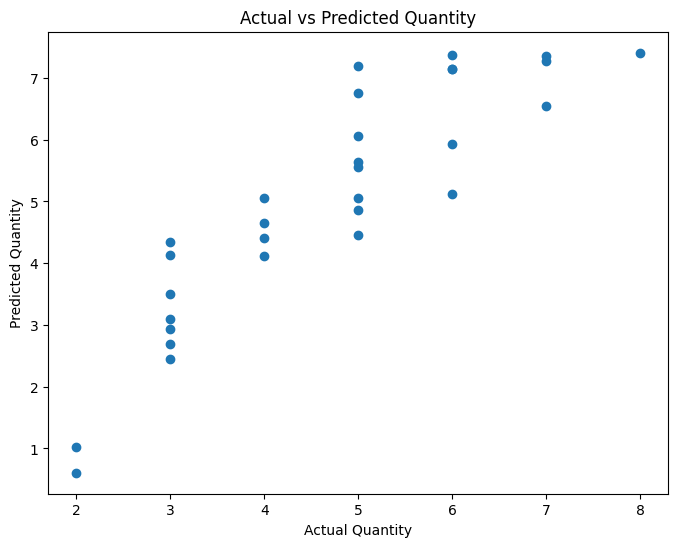

In [56]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Quantity")
plt.ylabel("Predicted Quantity")
plt.title("Actual vs Predicted Quantity")

plt.show()